# Google Play Store Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
apps_df = pd.read_csv('/content/apps.csv')

reviews_df = pd.read_csv('/content/user_reviews.csv')

In [ ]:
apps_df.head()


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [ ]:
apps_df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [ ]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
reviews_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
reviews_df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


## Data Cleaning

In [ ]:
apps_df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
apps_df['Rating'].describe()

,Rating
count,8196.000000
mean,4.173243
std,0.536625
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,5.000000


In [ ]:
apps_df['Rating'].fillna(apps_df['Rating'].median() , inplace=True)

/tmp/ipykernel_746/371521564.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df['Rating'].fillna(apps_df['Rating'].median() , inplace=True)


In [ ]:
apps_df['Current Ver'].describe()

,Current Ver
count,9651
unique,2769
top,Varies with device
freq,1055


In [ ]:
apps_df['Current Ver'].fillna(
    apps_df['Current Ver'].mode()[0],
    inplace=True
)

In [ ]:
apps_df['Android Ver'].fillna(
    apps_df['Android Ver'].mode()[0],
    inplace=True
)

/tmp/ipykernel_746/1189195220.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df['Android Ver'].fillna(


## Removing Unnecessary Columns

The columns **'Current Ver'** and **'Android Ver'** were removed from the dataset because they are not required for the current analysis. Removing irrelevant features helps simplify the dataset and improves analysis efficiency.

In [ ]:
apps_df.drop(columns=['Current Ver','Android Ver'], inplace=True )

In [ ]:
apps_df['Size'].unique()

array([ 19. ,  14. ,   8.7,  25. ,   2.8,   5.6,  29. ,  33. ,   3.1,
        28. ,  12. ,  20. ,  21. ,  37. ,   2.7,   5.5,  17. ,  39. ,
        31. ,   4.2,   7. ,  23. ,   6. ,   6.1,   4.6,   9.2,   5.2,
        11. ,  24. ,   nan,   9.4,  15. ,  10. ,   1.2,  26. ,   8. ,
         7.9,  56. ,  57. ,  35. ,  54. ,   0.2,   3.6,   5.7,   8.6,
         2.4,  27. ,   2.5,  16. ,   3.4,   8.9,   3.9,   2.9,  38. ,
        32. ,   5.4,  18. ,   1.1,   2.2,   4.5,   9.8,  52. ,   9. ,
         6.7,  30. ,   2.6,   7.1,   3.7,  22. ,   7.4,   6.4,   3.2,
         8.2,   9.9,   4.9,   9.5,   5. ,   5.9,  13. ,  73. ,   6.8,
         3.5,   4. ,   2.3,   7.2,   2.1,  42. ,   7.3,   9.1,  55. ,
         0. ,   6.5,   1.5,   7.5,  51. ,  41. ,  48. ,   8.5,  46. ,
         8.3,   4.3,   4.7,   3.3,  40. ,   7.8,   8.8,   6.6,   5.1,
        61. ,  66. ,   0.1,   8.4,  44. ,   0.7,   1.6,   6.2,  53. ,
         1.4,   3. ,   5.8,   3.8,   9.6,  45. ,  63. ,  49. ,  77. ,
         4.4,   4.8,

In [ ]:
apps_df['Size'].dtype

dtype('float64')

In [ ]:
apps_df['Size'].fillna(
    apps_df['Size'].median(),
    inplace=True
)

/tmp/ipykernel_746/1288168888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df['Size'].fillna(


In [ ]:
apps_df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
apps_df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Size', ylabel='Rating'>

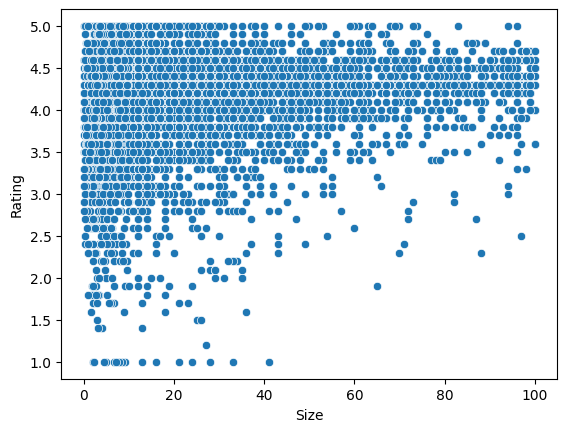

In [ ]:
sns.scatterplot(
    x='Size',
    y='Rating',
    data=apps_df
)

In [ ]:
apps_df[['Reviews','Installs','Price']].dtypes

,0
Reviews,int64
Installs,object
Price,object


In [ ]:
apps_df['Installs'].unique()[:10]

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+'],
      dtype=object)

In [ ]:
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')


apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)


apps_df['Installs'] = apps_df['Installs'].astype(int)

In [ ]:
apps_df['Installs'].dtype


dtype('int64')

In [ ]:
apps_df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [ ]:
apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False)

apps_df['Price'] = apps_df['Price'].astype(float)

In [ ]:
apps_df['Price'].dtype

dtype('float64')

In [ ]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          9659 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            9659 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9659 non-null   object 
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Last Updated    9659 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 830.2+ KB


#Visualization

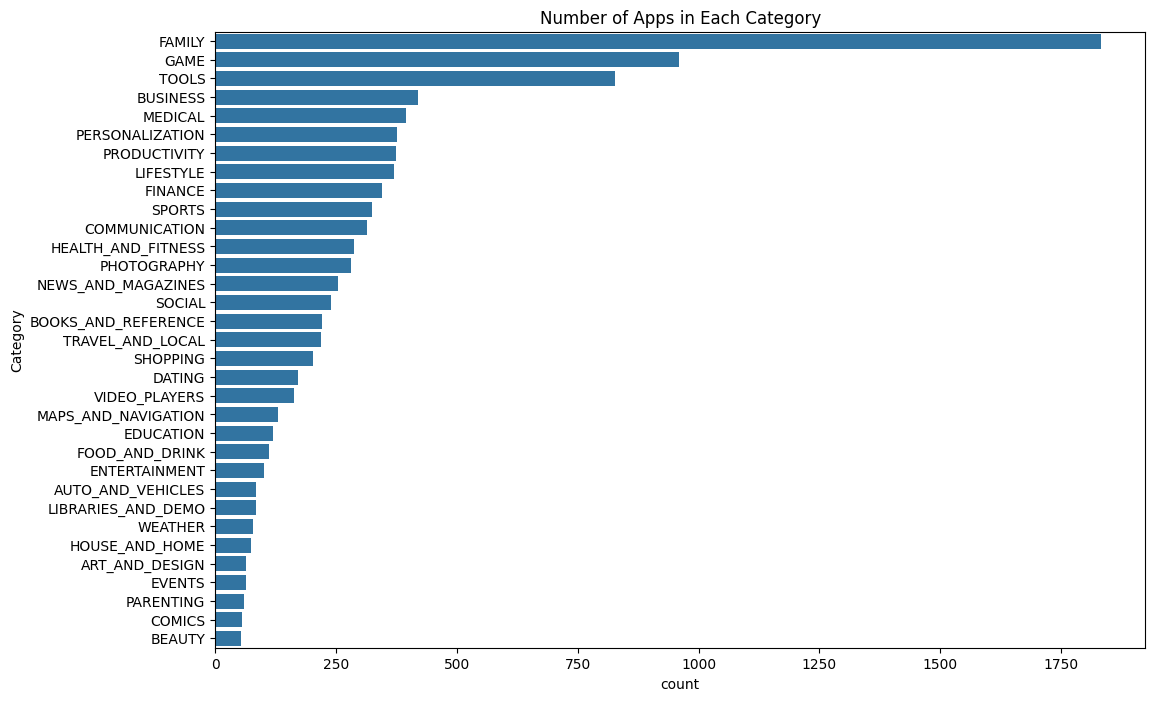

In [ ]:
plt.figure(figsize=(12,8))

sns.countplot(
    y='Category',
    data=apps_df,
    order=apps_df['Category'].value_counts().index
)

plt.title('Number of Apps in Each Category')
plt.show()

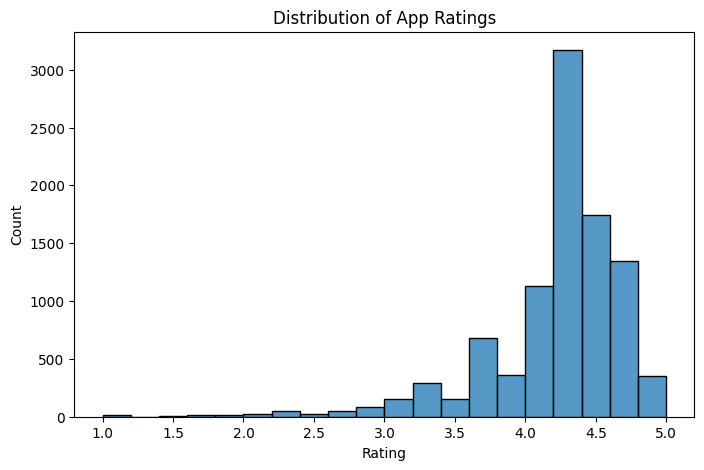

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps_df['Rating'],
    bins=20
)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

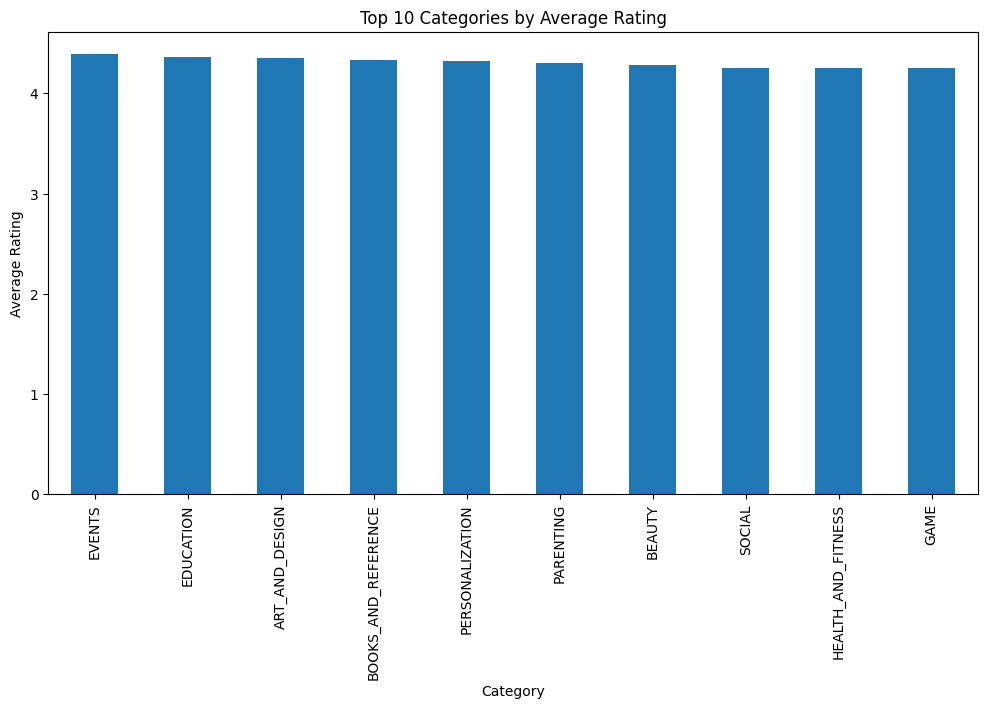

In [ ]:
top_rating = apps_df.groupby(
    'Category'
)['Rating'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

top_rating.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Categories by Average Rating')
plt.ylabel('Average Rating')
plt.show()

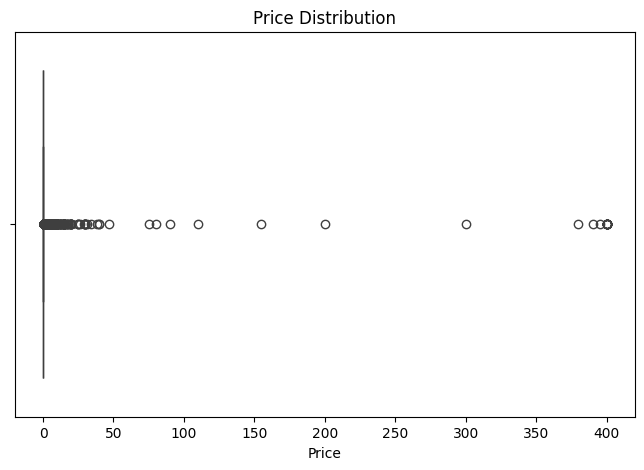

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=apps_df['Price']
)

plt.title('Price Distribution')
plt.show()

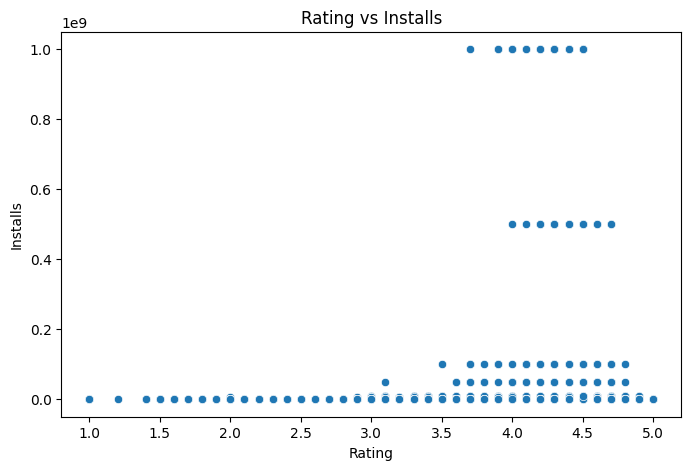

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Rating',
    y='Installs',
    data=apps_df
)

plt.title('Rating vs Installs')
plt.show()

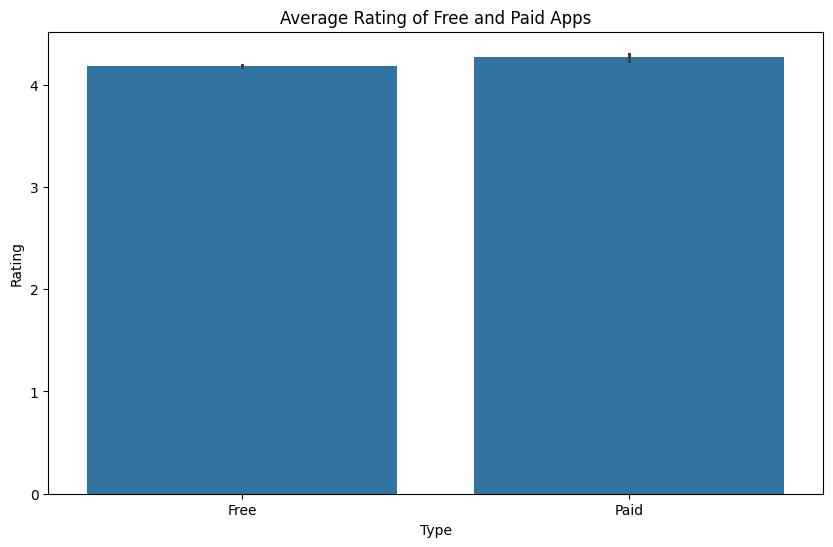

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Type',
    y='Rating',
    data=apps_df
)

plt.title('Average Rating of Free and Paid Apps')
plt.show()

In [ ]:
reviews_df.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


#Cleaning of Reviews Dataset


In [ ]:
reviews_df.duplicated().sum()

np.int64(0)

In [ ]:
reviews_df.drop_duplicates(inplace=True)

In [ ]:
reviews_df.dropna(
    subset=['Translated_Review'],
    inplace=True
)

In [ ]:
reviews_df['Sentiment'].value_counts()

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4356


##Visualization

## User Sentiment Analysis

User reviews were analyzed and classified into:
- Positive
- Negative
- Neutral

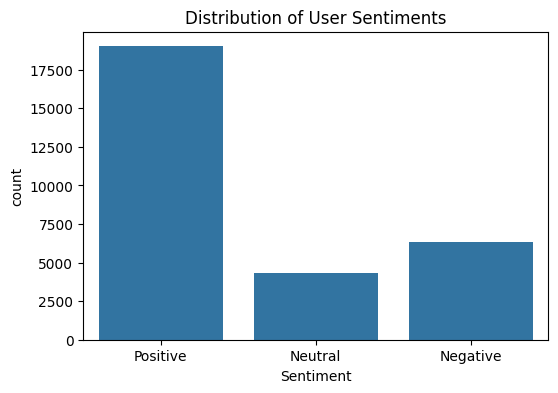

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sentiment',
    data=reviews_df
)

plt.title('Distribution of User Sentiments')
plt.show()

In [ ]:
top_apps = reviews_df.groupby(
    'App'
)['Sentiment_Polarity'].mean().sort_values(
    ascending=False
)

top_apps.head(10)

,Sentiment_Polarity
App,
HomeWork,1.000000
Google Slides,0.933333
Daily Workouts - Exercise Fitness Routine Trainer,0.800000
Bed Time Fan - White Noise Sleep Sounds,0.781250
Cameringo Lite. Filters Camera,0.770269
Google Primer,0.750000
GPS Map Free,0.700000
GPS Speedometer and Odometer,0.650000
Best Ovulation Tracker Fertility Calendar App Glow,0.595313


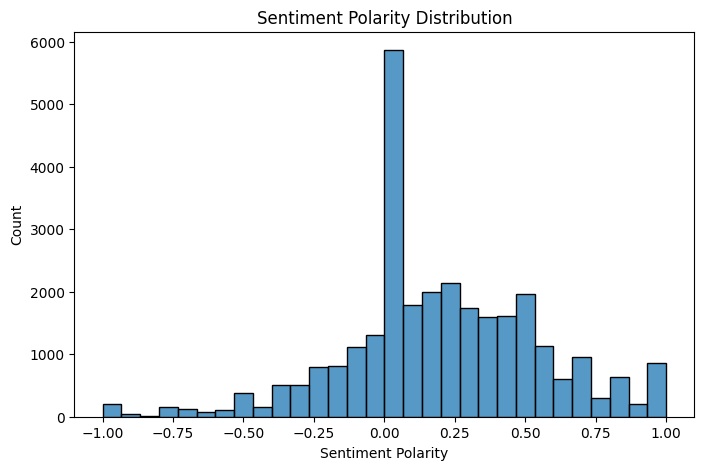

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    reviews_df['Sentiment_Polarity'],
    bins=30
)

plt.title('Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity')
plt.show()

##Final Insights

Most apps on the Google Play Store are free.

Family, Game, and Tools categories dominate the marketplace.

Most apps receive ratings above 4.0, indicating generally positive user experiences.

Positive user sentiment significantly outweighs negative sentiment.

Higher-rated apps tend to attract more installs.

Pricing has limited impact because the majority of apps are offered for free

##Recommendations

Developers should focus on maintaining high ratings through continuous updates and user engagement.

Monitoring user sentiment can help identify areas for improvement.

Categories with high demand and positive sentiment present opportunities for new app development.

App publishers should prioritize user satisfaction to increase installs and retention